In [1]:
# setup and load libraries
import torch.nn as nn
import numpy as np
import main, cv2, torch, scipy.io
import matplotlib.pyplot as plt
import torch.nn.utils.parametrizations as para
from utils.dataset import DataSet, gamma_correct
from sklearn.decomposition import PCA
from models.denoiser import Denoiser
from skimage.metrics import peak_signal_noise_ratio as psnr
from inverse.orthogonal import LinearInverse, batch_recon
from tqdm import tqdm
from scipy.linalg import subspace_angles
from utils.dataset import MNIST, CelebA

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
import seaborn as sns
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
plt.rcParams['figure.dpi'] = 300

### Compute PCAs

MNIST

In [3]:
data = MNIST()
train_mnist = data.train_set()
test_mnist = data.test_set()

In [4]:
# compute PCA solution
train_torch = torch.from_numpy(train_mnist)

image_vec = train_torch.permute([0, 3, 2, 1]).flatten(1).numpy()
pca = PCA(n_components=image_vec.shape[-1])
pca.fit(image_vec)

# n_comp, n_features
pcs_mnist = pca.components_
print('PCA:', pcs_mnist.shape)

PCA: (784, 784)


In [5]:
# split into first and second halfs

n_data = image_vec.shape[0]
index = np.array(range(n_data))
np.random.shuffle(index)

pca = PCA(n_components=image_vec.shape[-1])
pca.fit(image_vec[index[:n_data // 2], :])
mnist_fh = pca.components_

np.random.shuffle(index)
pca = PCA(n_components=image_vec.shape[-1])
pca.fit(image_vec[index[:n_data // 2], :])
mnist_sh = pca.components_

split_mnist = [mnist_fh, mnist_sh]

CelebA

In [3]:
data = CelebA(from_numpy=True)
train_celeba = data.train_set()

N_TEST = 512
test_celeba = data.test_set()[:N_TEST]

In [4]:
# compute PCA solution
train_torch = torch.from_numpy(train_celeba)

image_vec = train_torch.permute([0, 3, 2, 1]).flatten(1).numpy()
pca = PCA(n_components=image_vec.shape[-1])
pca.fit(image_vec)

# n_comp, n_features
pcs_celeba = pca.components_
print('PCA:', pcs_celeba.shape)

PCA: (6400, 6400)


In [5]:
# split into first and second halfs

n_data = image_vec.shape[0]
index = np.array(range(n_data))
np.random.shuffle(index)

pca = PCA(n_components=image_vec.shape[-1])
pca.fit(image_vec[index[:n_data // 2], :])
celeba_fh = pca.components_

np.random.shuffle(index)
pca = PCA(n_components=image_vec.shape[-1])
pca.fit(image_vec[index[:n_data // 2], :])
celeba_sh = pca.components_

split_celeba = [celeba_fh, celeba_sh]

### Analysis Linear Subspace

MNIST - Measurement Vector

In [6]:
n_sample = 64
train_torch = torch.from_numpy(train_mnist)
image_vec = train_torch.permute([0, 3, 2, 1]).flatten(1).numpy()
test_torch = torch.tensor(test_mnist).permute([0, 3, 1, 2]).to(device)

np_size = [*train_mnist.shape[-3:]]
im_size = test_torch.size()[1:]
n_pixel = np.prod(im_size)

In [7]:
pca_mtx = pcs_mnist

base_path = './olm_result/MNIST/all_digit/%d_MSE_mnist.npy'
file_path = base_path % n_sample

order = 5
with open(file_path, 'rb') as fl:
    for count in range(order):
        opt_mtx = np.load(fl)

target_shape = [-1, im_size[0], im_size[2], im_size[1]]
pca_image = pca_mtx.reshape(target_shape).transpose([0, 3, 2, 1])
opt_image = opt_mtx.reshape(target_shape).transpose([0, 3, 2, 1])

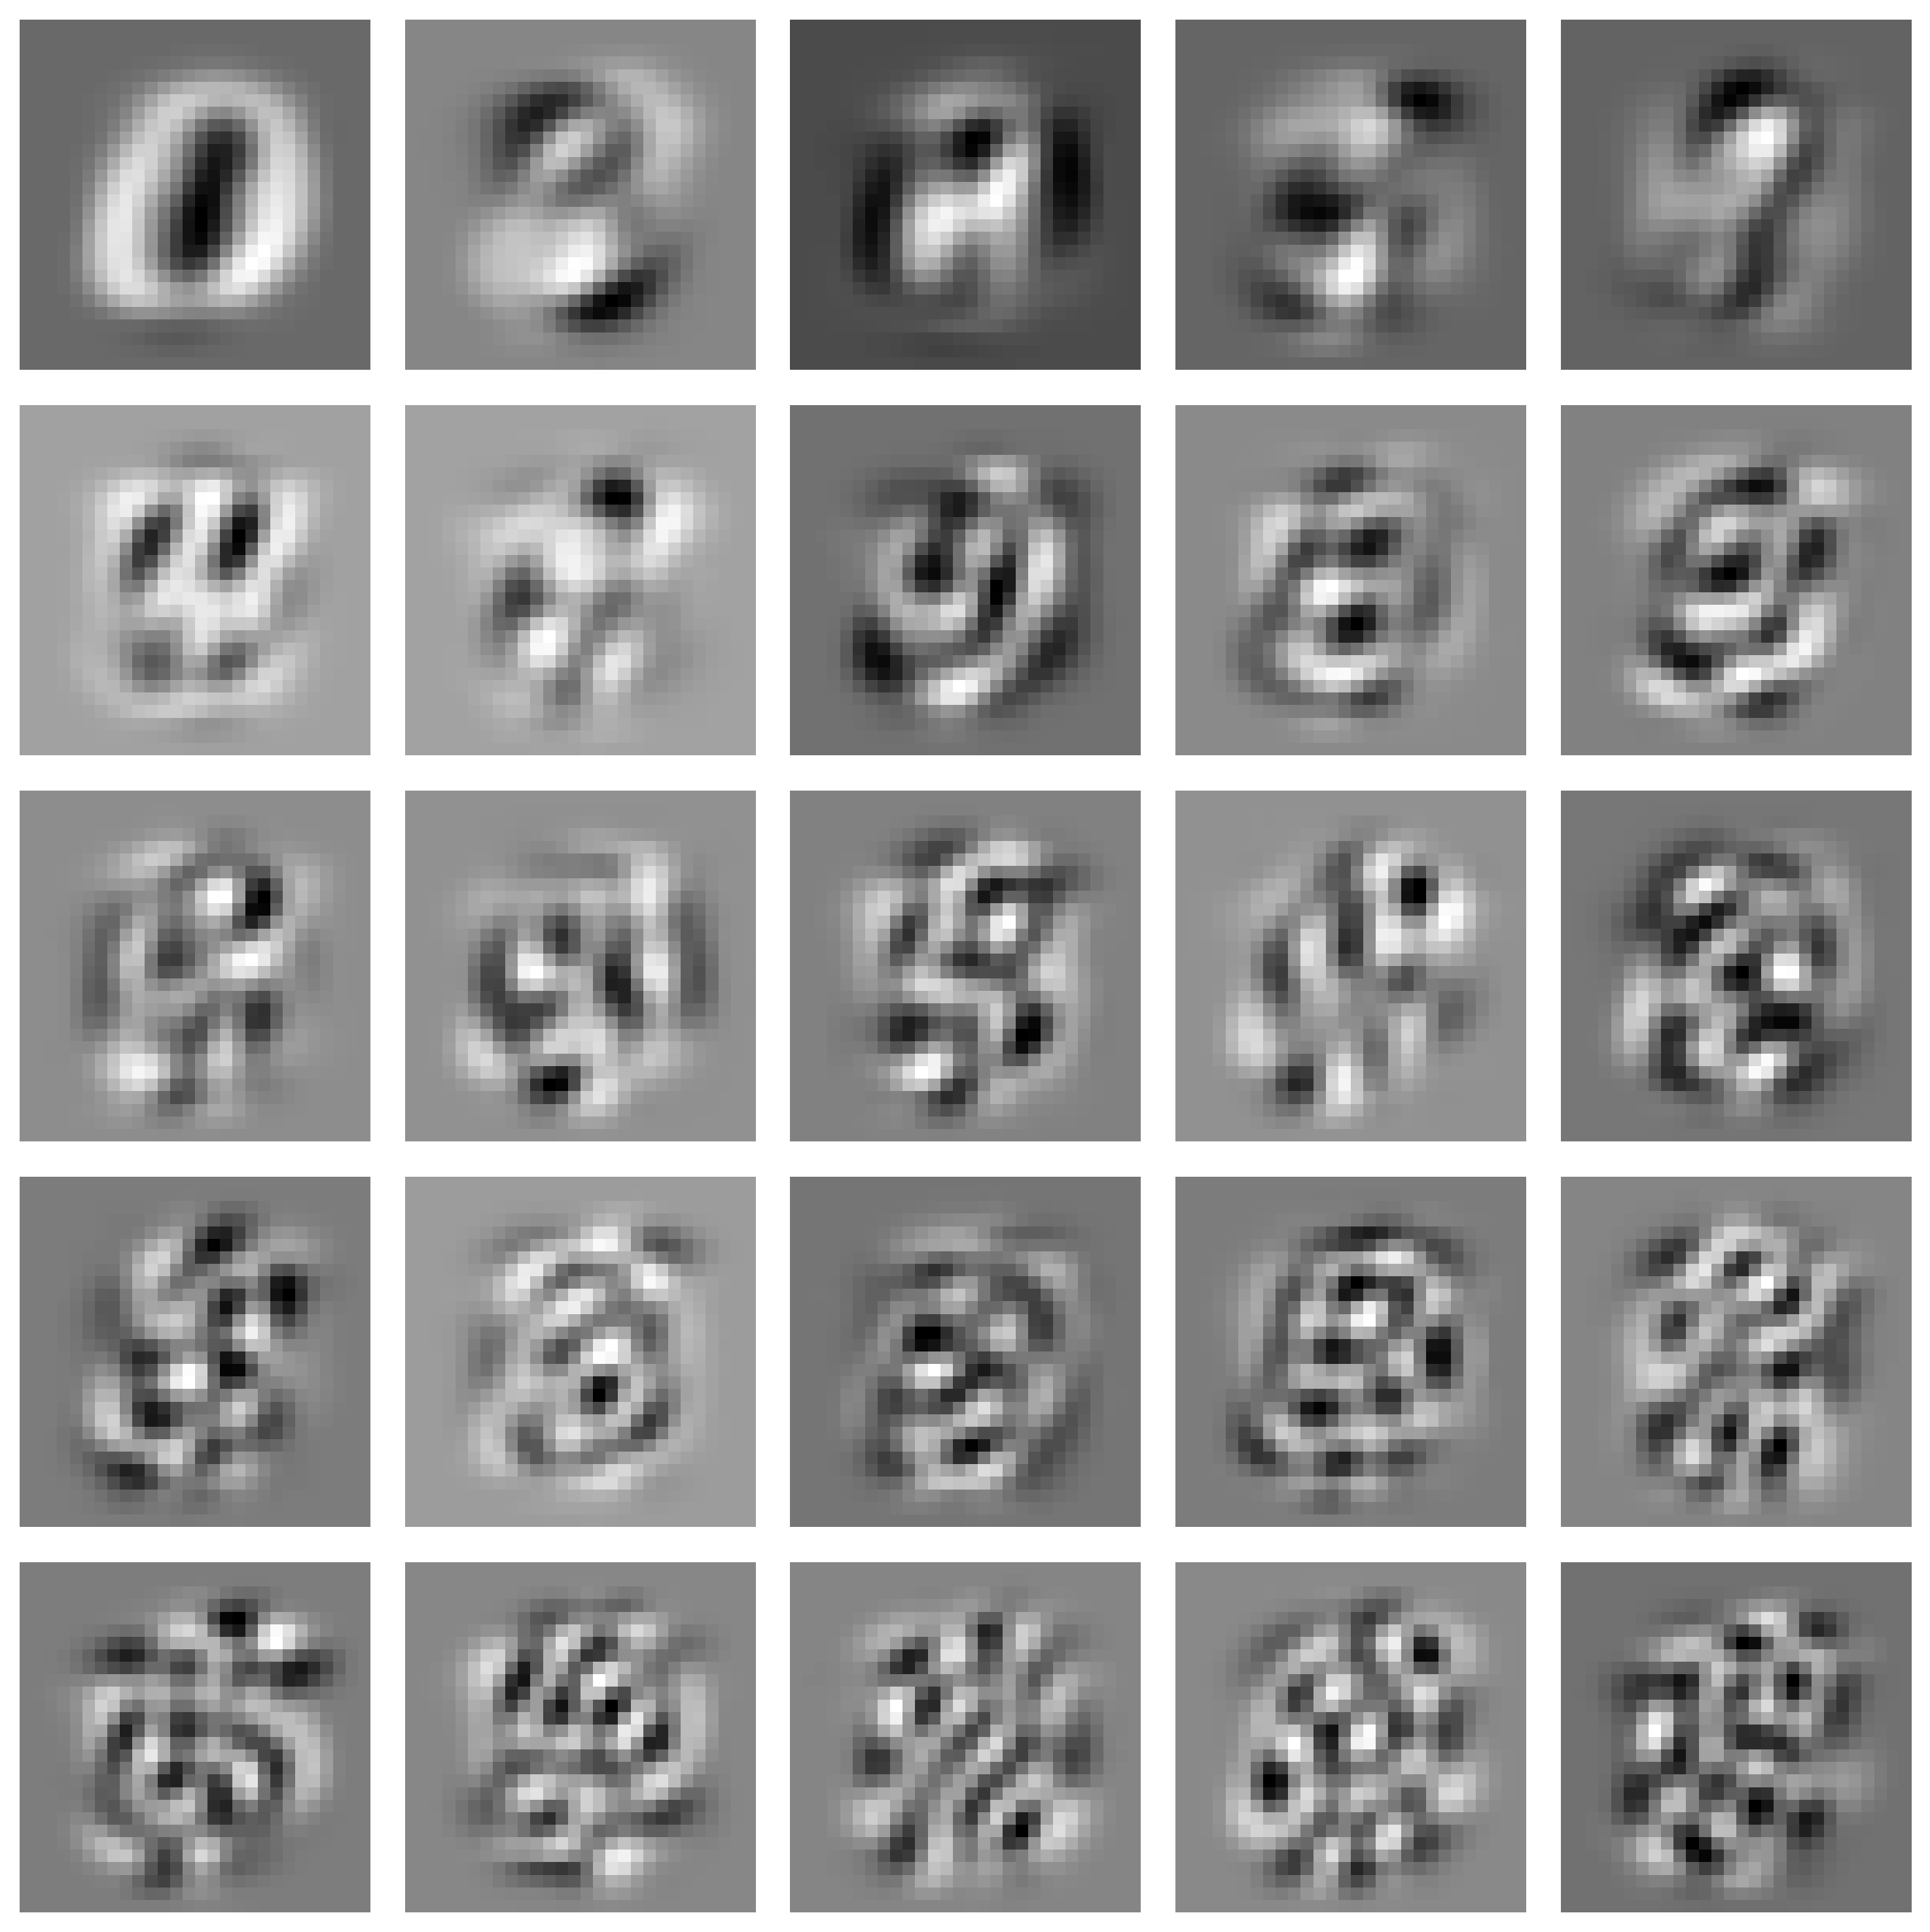

In [8]:
n_step = 2

n_row = 5
n_col = 5

fig, axs = plt.subplots(n_row, n_col, figsize=(n_col*2, n_row*2))
for idx in range(n_row * n_col):
    # normalization
    image = pca_image[idx * n_step]
    image = image - np.min(image)
    image = image / np.max(image)
    
    # show image
    axs.flat[idx].imshow(image, cmap='gray')
    axs.flat[idx].axis('off')
    
fig.tight_layout()

fig_name = 'mnist_pc'
fig.savefig('./%s.pdf' % fig_name, bbox_inches='tight')

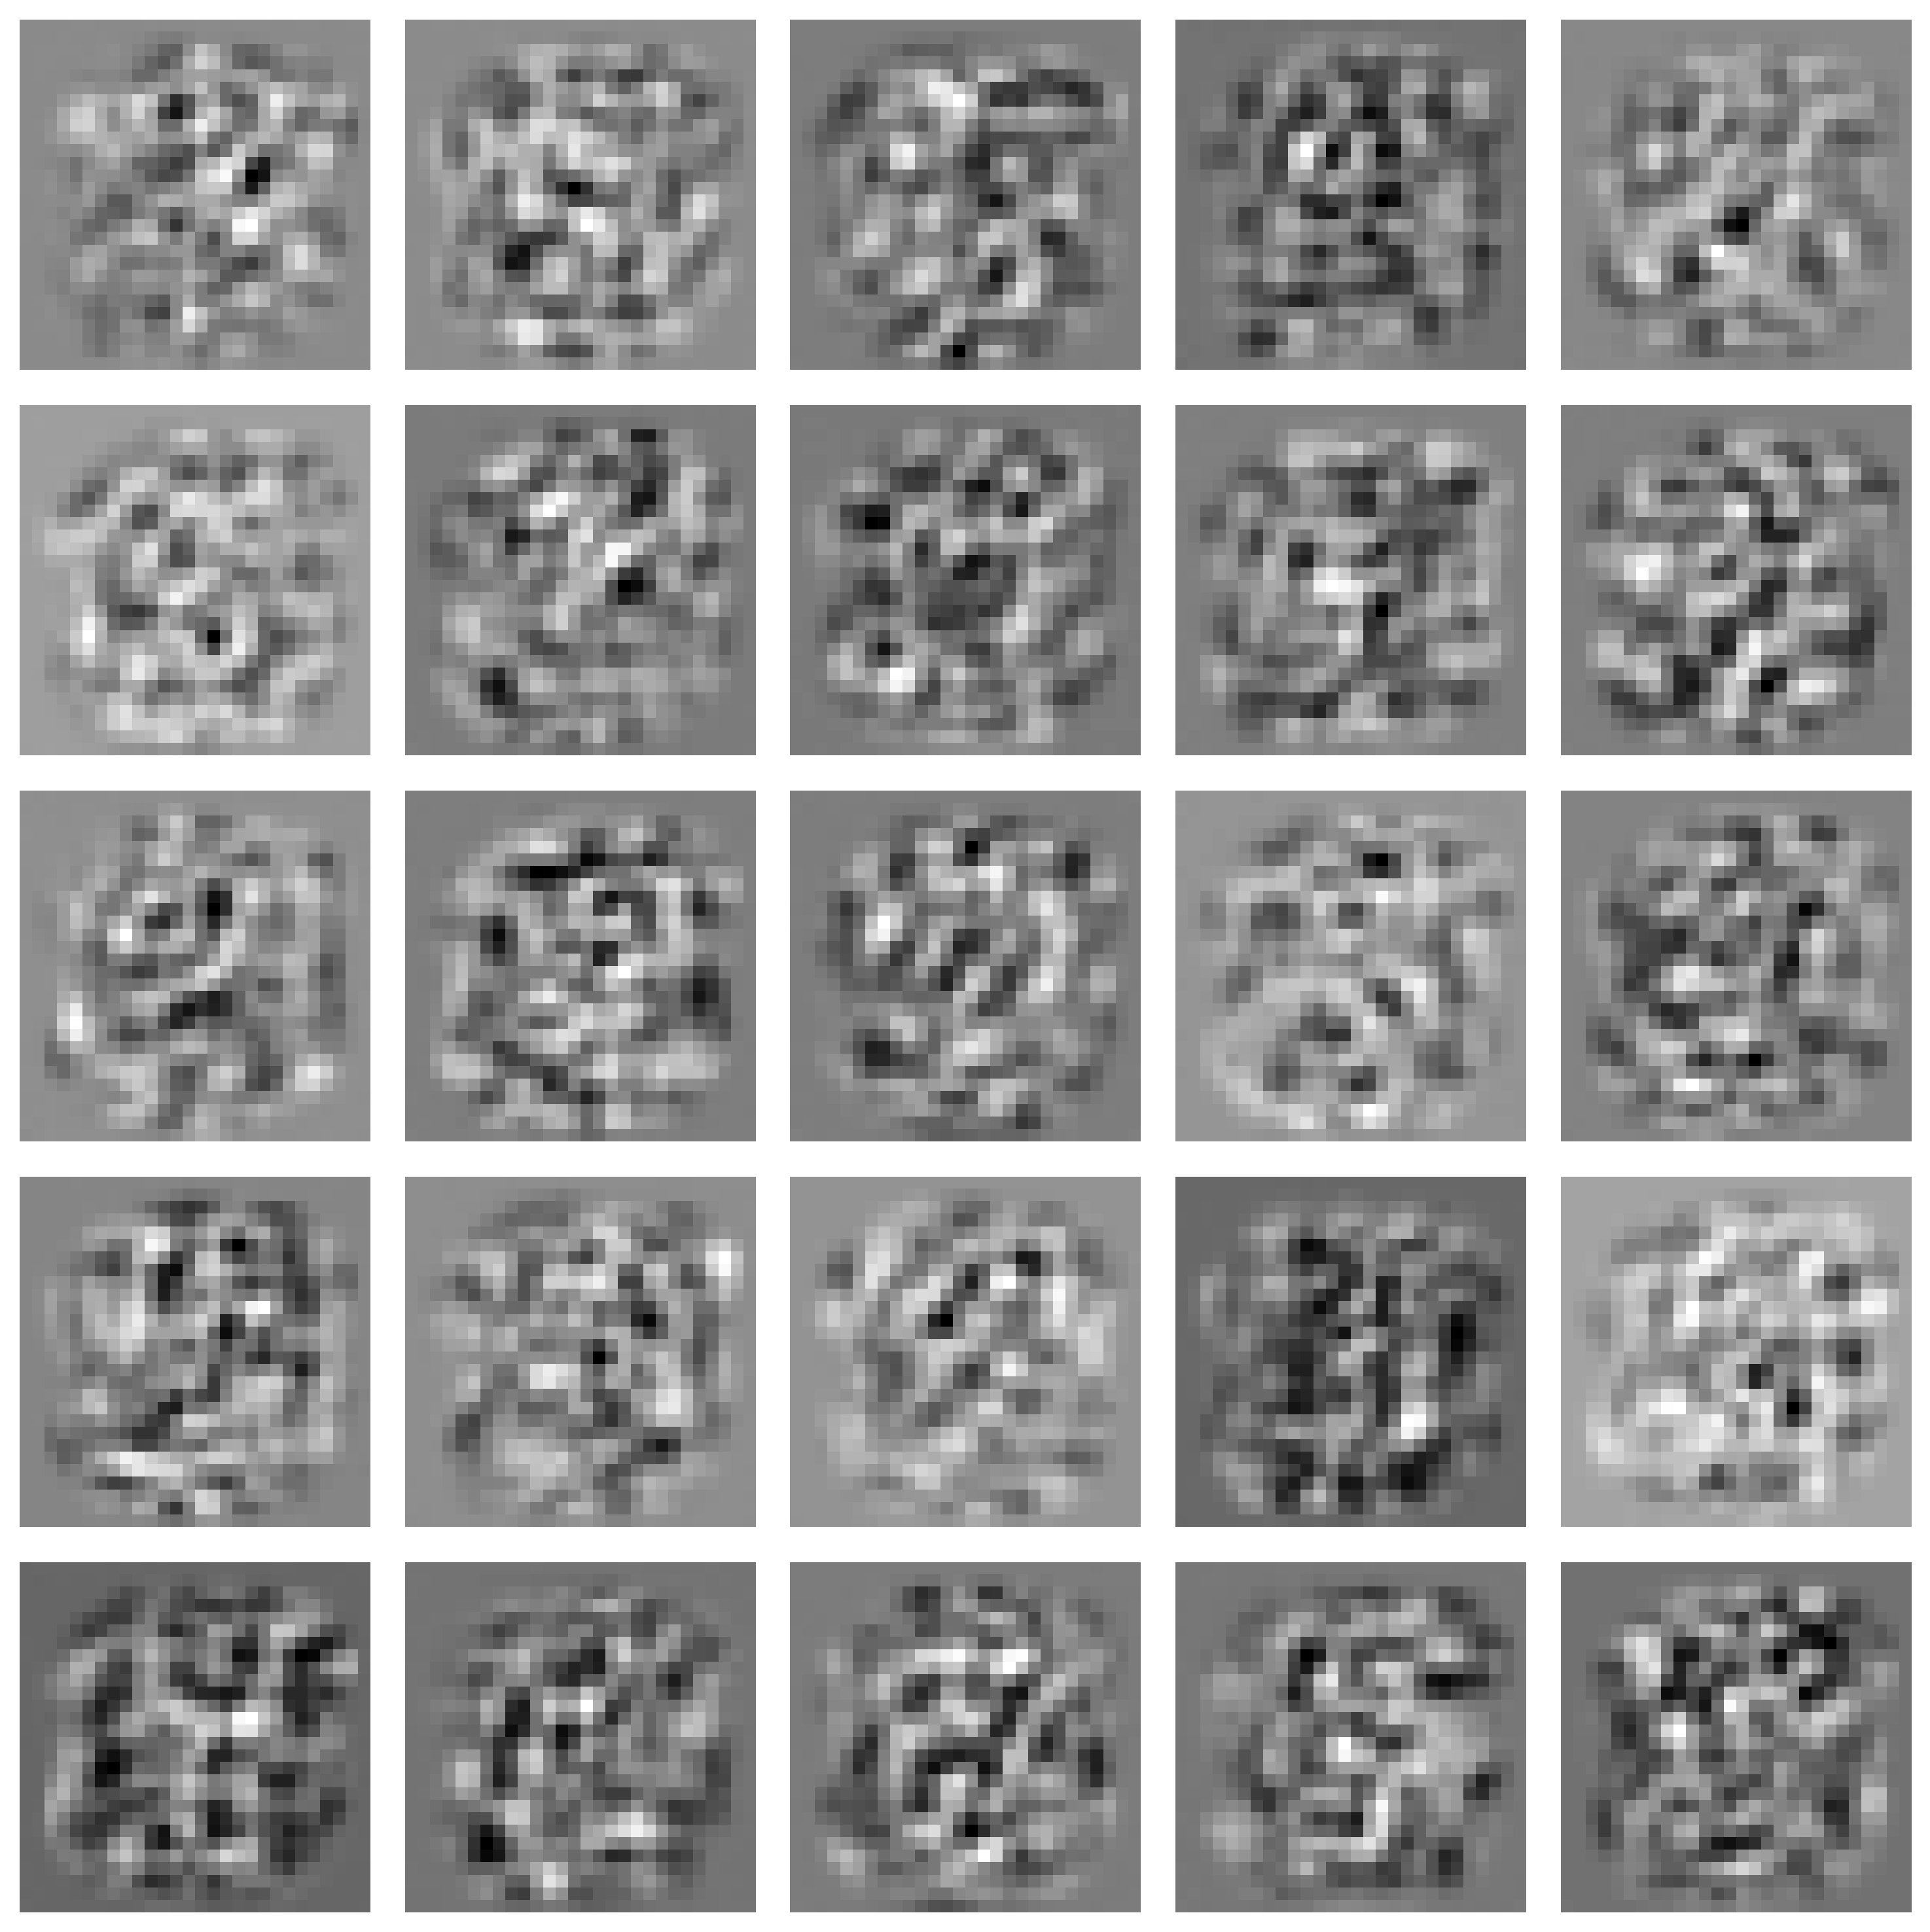

In [9]:
n_step = 2

n_row = 5
n_col = 5

fig, axs = plt.subplots(n_row, n_col, figsize=(n_col*2, n_row*2))
for idx in range(n_row * n_col):
    # normalization
    image = opt_image[idx * n_step]
    image = image - np.min(image)
    image = image / np.max(image)
    
    # show image
    axs.flat[idx].imshow(image, cmap='gray')
    axs.flat[idx].axis('off')
    
fig.tight_layout()

fig_name = 'mnist_olm'
fig.savefig('./%s.pdf' % fig_name, bbox_inches='tight')

Variance Drop-off

In [10]:
n_sample = 512
pca_mtx = pca.components_[:n_sample, :]

base_path = './olm_result/MNIST/all_digit/%d_MSE_mnist.npy'
file_path = base_path % n_sample

order = 5
with open(file_path, 'rb') as fl:
    for count in range(order):
        opt_mtx = np.load(fl)

# variance PC
pc_proj = pca_mtx @ image_vec.T
pc_var = np.var(pc_proj, axis=1)

# variance Opt Mtx
opt_proj = opt_mtx @ image_vec.T
opt_var = np.var(opt_proj, axis=1)
opt_sorted = np.sort(opt_var)[::-1]

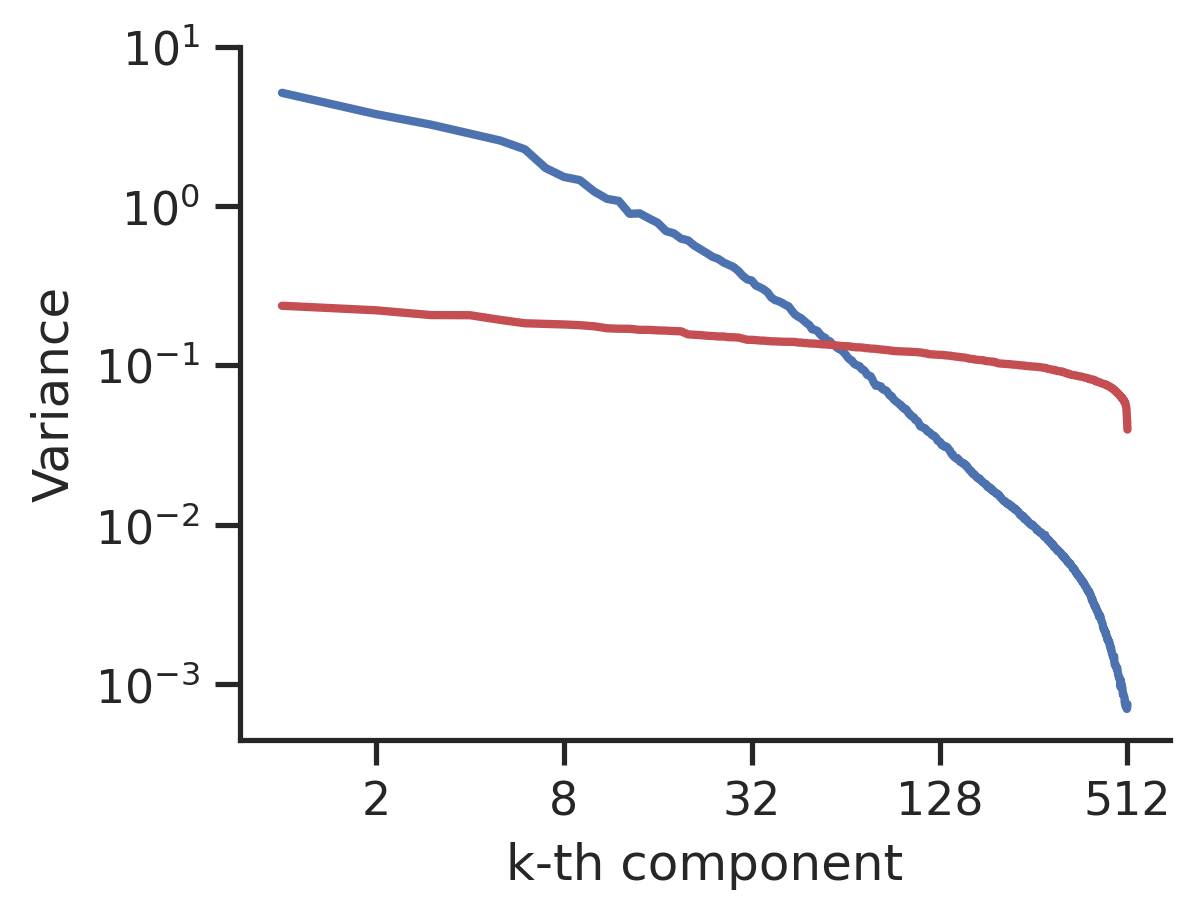

In [16]:
fig = plt.figure(figsize=(4, 3))

plt.plot(np.array(range(n_sample)) + 1, pc_var, linewidth=2)
plt.plot(np.array(range(n_sample)) + 1, opt_sorted, 'r', linewidth=2)

x_ticks = np.array([1, 3, 5, 7, 9])
plt.xscale('log', base=2)
plt.xticks(2 ** x_ticks, 
           2 ** x_ticks)

plt.yscale('log')
plt.yticks(10.0 ** np.array([-3, -2, -1, 0, 1]))
plt.minorticks_off()
plt.xlabel('k-th component')
plt.ylabel('Variance')

fig_name = 'mnist_var'
fig.savefig('./%s.pdf' % fig_name, bbox_inches='tight')

fig.show()

Linear Subspace

In [12]:
samples = [2, 4, 8, 16, 32, 
           64, 128, 256, 512]

rand_mtx = np.random.normal(size=(n_pixel, n_pixel))
u, _, _ = np.linalg.svd(rand_mtx)

In [13]:
dist = [[], [], []]
pcs = pcs_mnist
split = split_mnist

for idx in range(len(samples)):
    n_sample = samples[idx]
    
    file_path = base_path % n_sample
    with open(file_path, 'rb') as fl:
        for count in range(order):
            opt_mtx = np.load(fl)
    
    # PC - PC
    fh = split[0][:n_sample, :]
    sh = split[1][:n_sample, :]
    angle = subspace_angles(fh.T, sh.T)
    dist[0].append(np.linalg.norm(angle))
    
    # PC - OPT
    pc = pcs[:n_sample, :]
    angle = subspace_angles(pc.T, opt_mtx.T)
    dist[1].append(np.linalg.norm(angle)) 
    
    # PC - RND
    rnd = u[:n_sample, :]
    angle = subspace_angles(pc.T, rnd.T)
    dist[2].append(np.linalg.norm(angle)) 

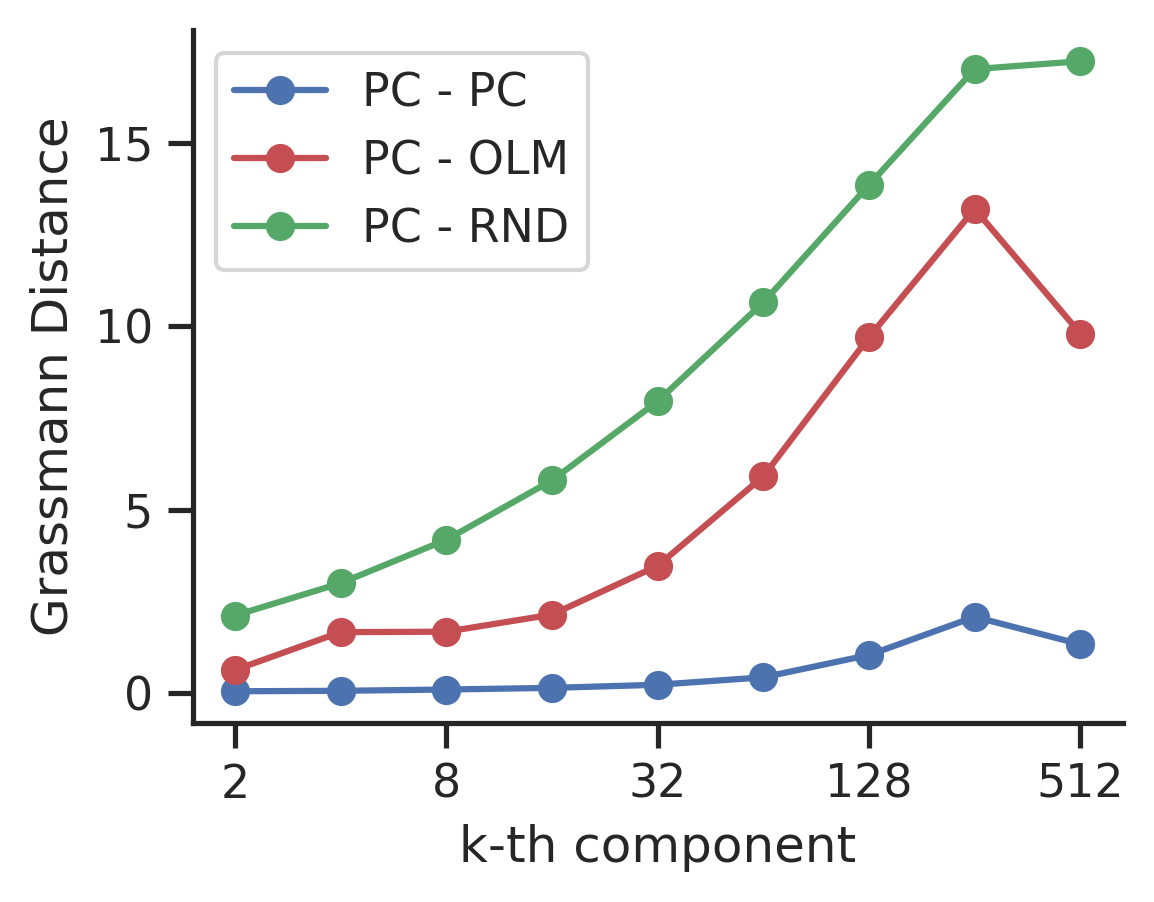

In [14]:
fig = plt.figure(figsize=(4, 3))

colors = ['b', 'r', 'g']
for idx in range(len(dist)):
    plt.plot(samples, dist[idx], '-o%s' % colors[idx])        

x_ticks = np.array([1, 3, 5, 7, 9])
plt.xscale('log', base=2)
plt.xticks(2 ** x_ticks, 
           2 ** x_ticks)

plt.legend(['PC - PC', 'PC - OLM', 'PC - RND'])

plt.xlabel('k-th component')
plt.ylabel('Grassmann Distance')

fig_name = 'mnist_dist'
fig.savefig('./%s.pdf' % fig_name, bbox_inches='tight')
    
plt.show()

### Analysis for CelebA

In [7]:
n_sample = 64
train_torch = torch.from_numpy(train_celeba)
image_vec = train_torch.permute([0, 3, 2, 1]).flatten(1).numpy()
test_torch = torch.tensor(test_celeba).permute([0, 3, 1, 2]).to(device)

np_size = [*train_celeba.shape[-3:]]
im_size = test_torch.size()[1:]
n_pixel = np.prod(im_size)

In [8]:
pca_mtx = pcs_celeba

base_path = './olm_result/CelebA/%d_MSE_celeba.npy'
file_path = base_path % n_sample

order = 5
with open(file_path, 'rb') as fl:
    for count in range(order):
        opt_mtx = np.load(fl)

target_shape = [-1, im_size[0], im_size[2], im_size[1]]
pca_image = pca_mtx.reshape(target_shape).transpose([0, 3, 2, 1])
opt_image = opt_mtx.reshape(target_shape).transpose([0, 3, 2, 1])

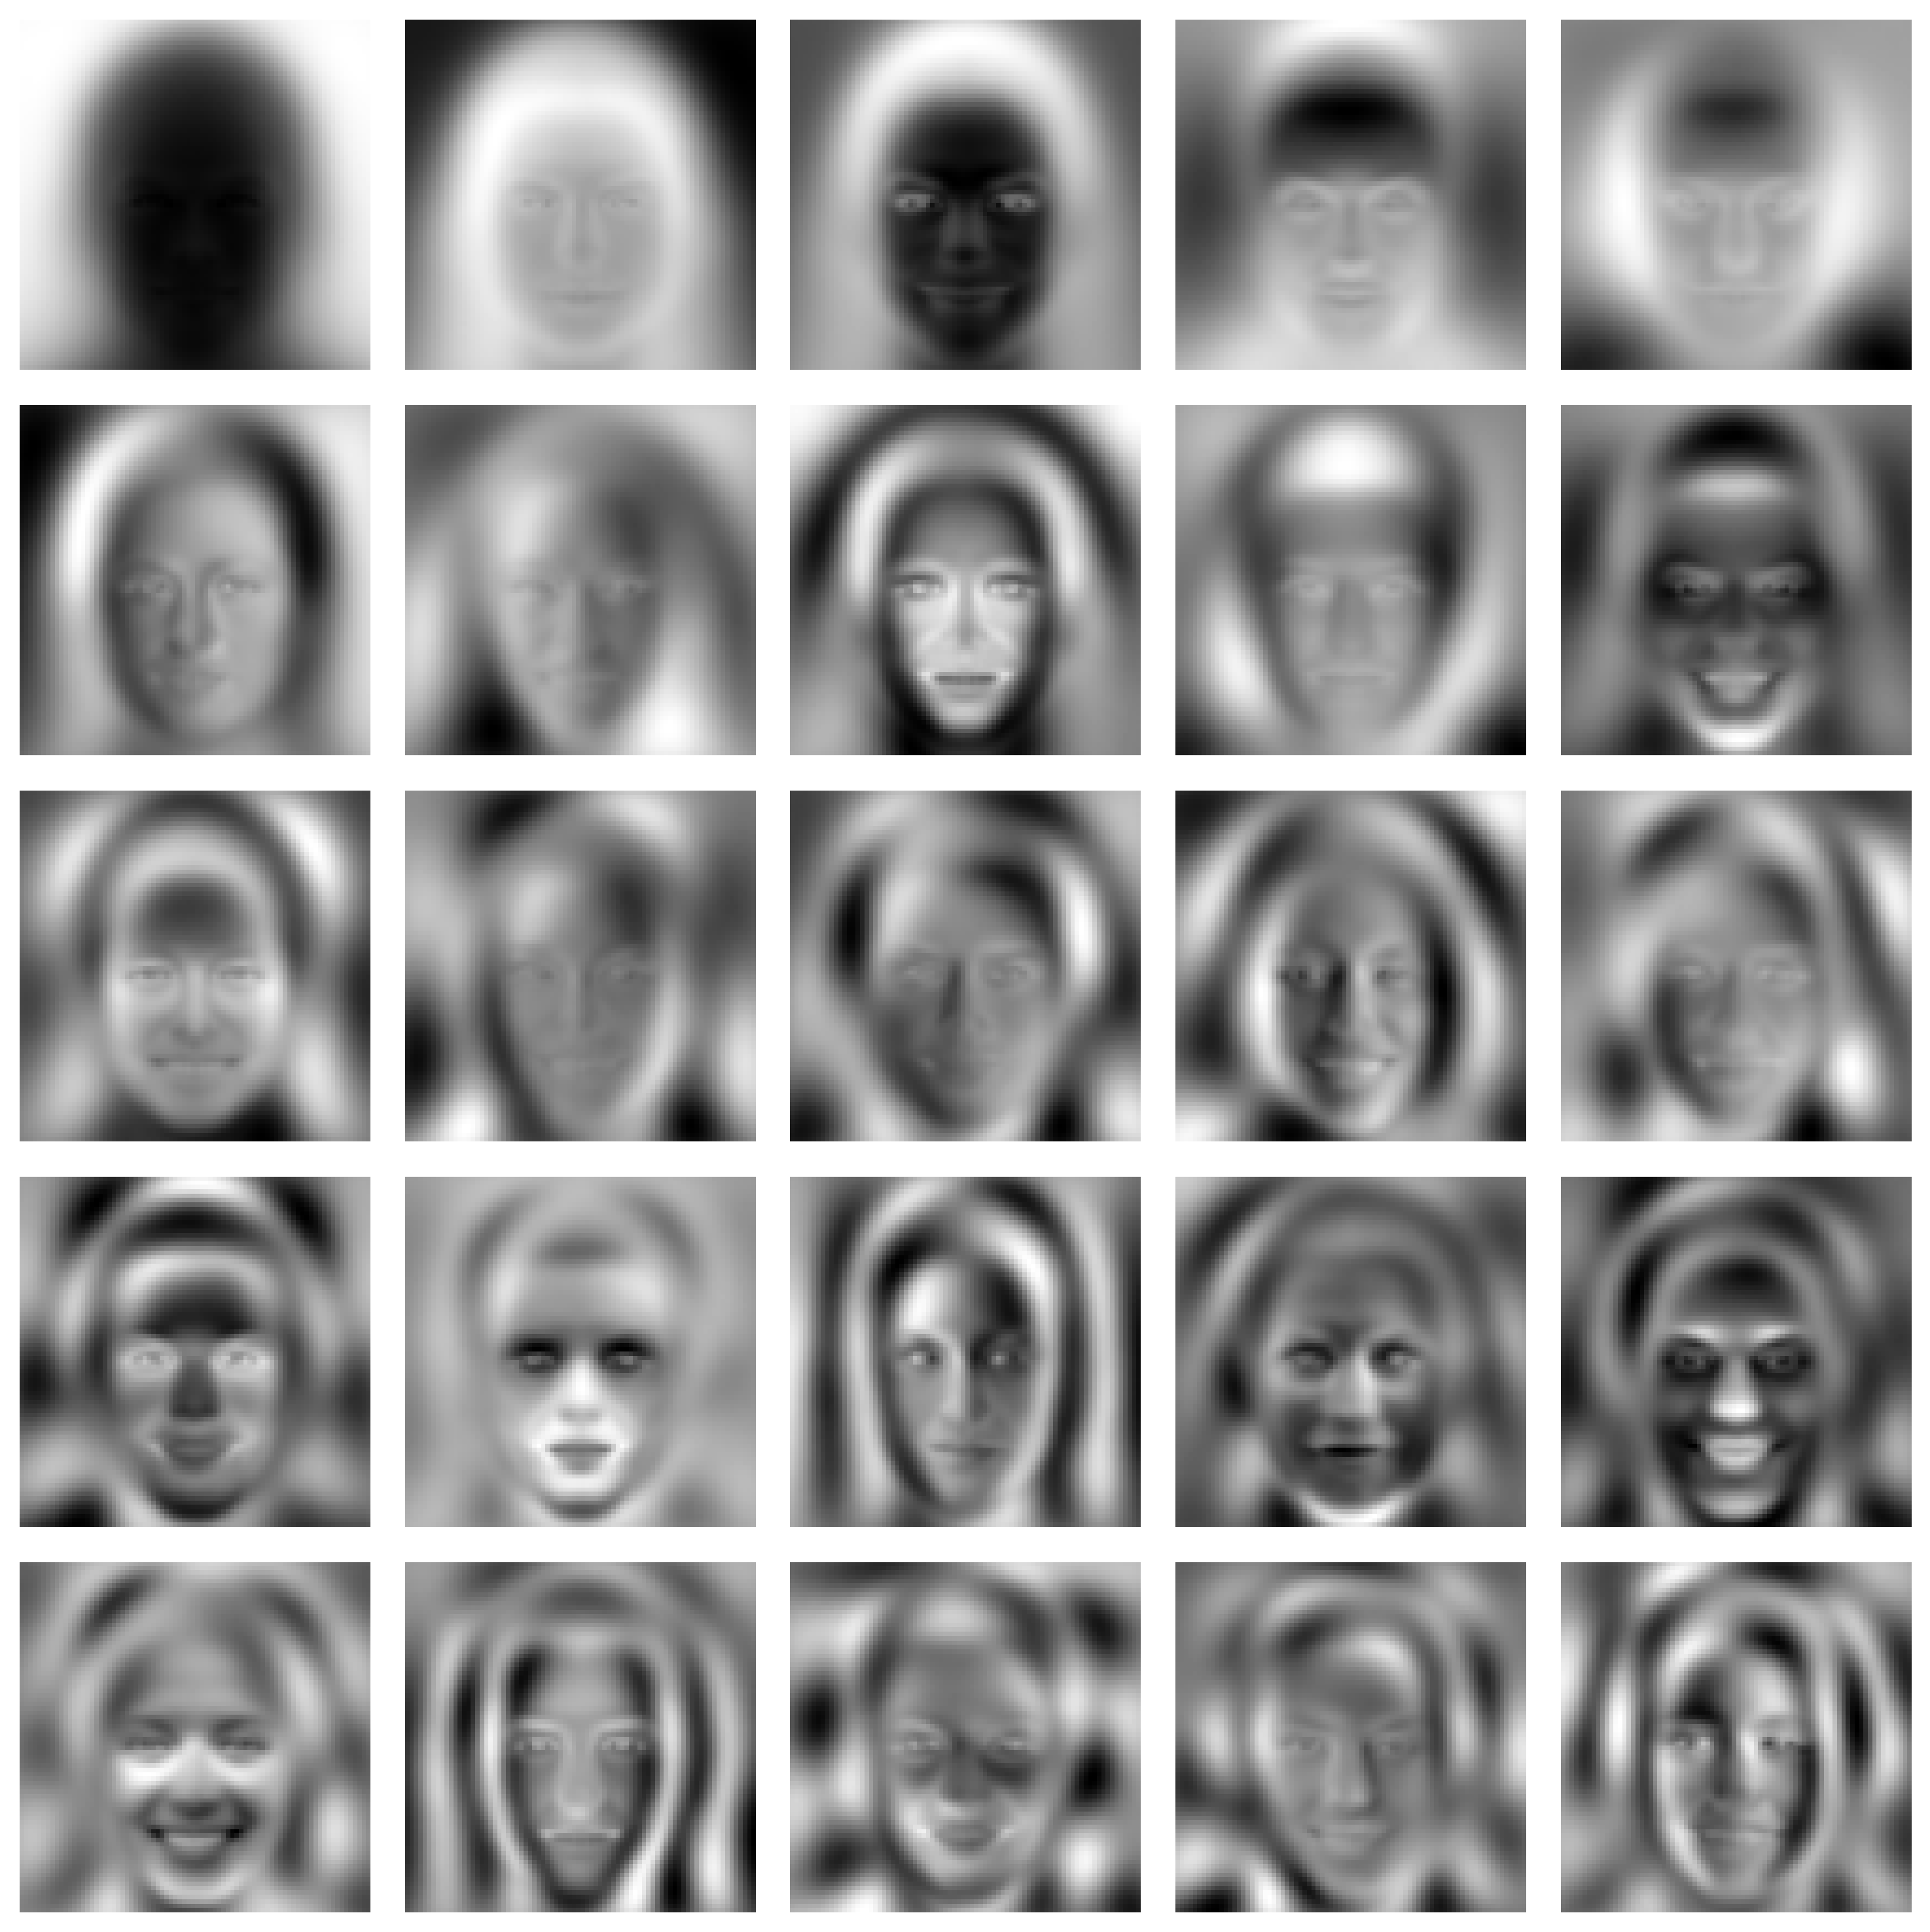

In [9]:
n_step = 2

n_row = 5
n_col = 5

fig, axs = plt.subplots(n_row, n_col, figsize=(n_col*2, n_row*2))
for idx in range(n_row * n_col):
    # normalization
    image = pca_image[idx * n_step]
    image = image - np.min(image)
    image = image / np.max(image)
    
    # show image
    axs.flat[idx].imshow(image, cmap='gray')
    axs.flat[idx].axis('off')
    
fig.tight_layout()

fig_name = 'celeba_pc'
fig.savefig('./%s.pdf' % fig_name, bbox_inches='tight')

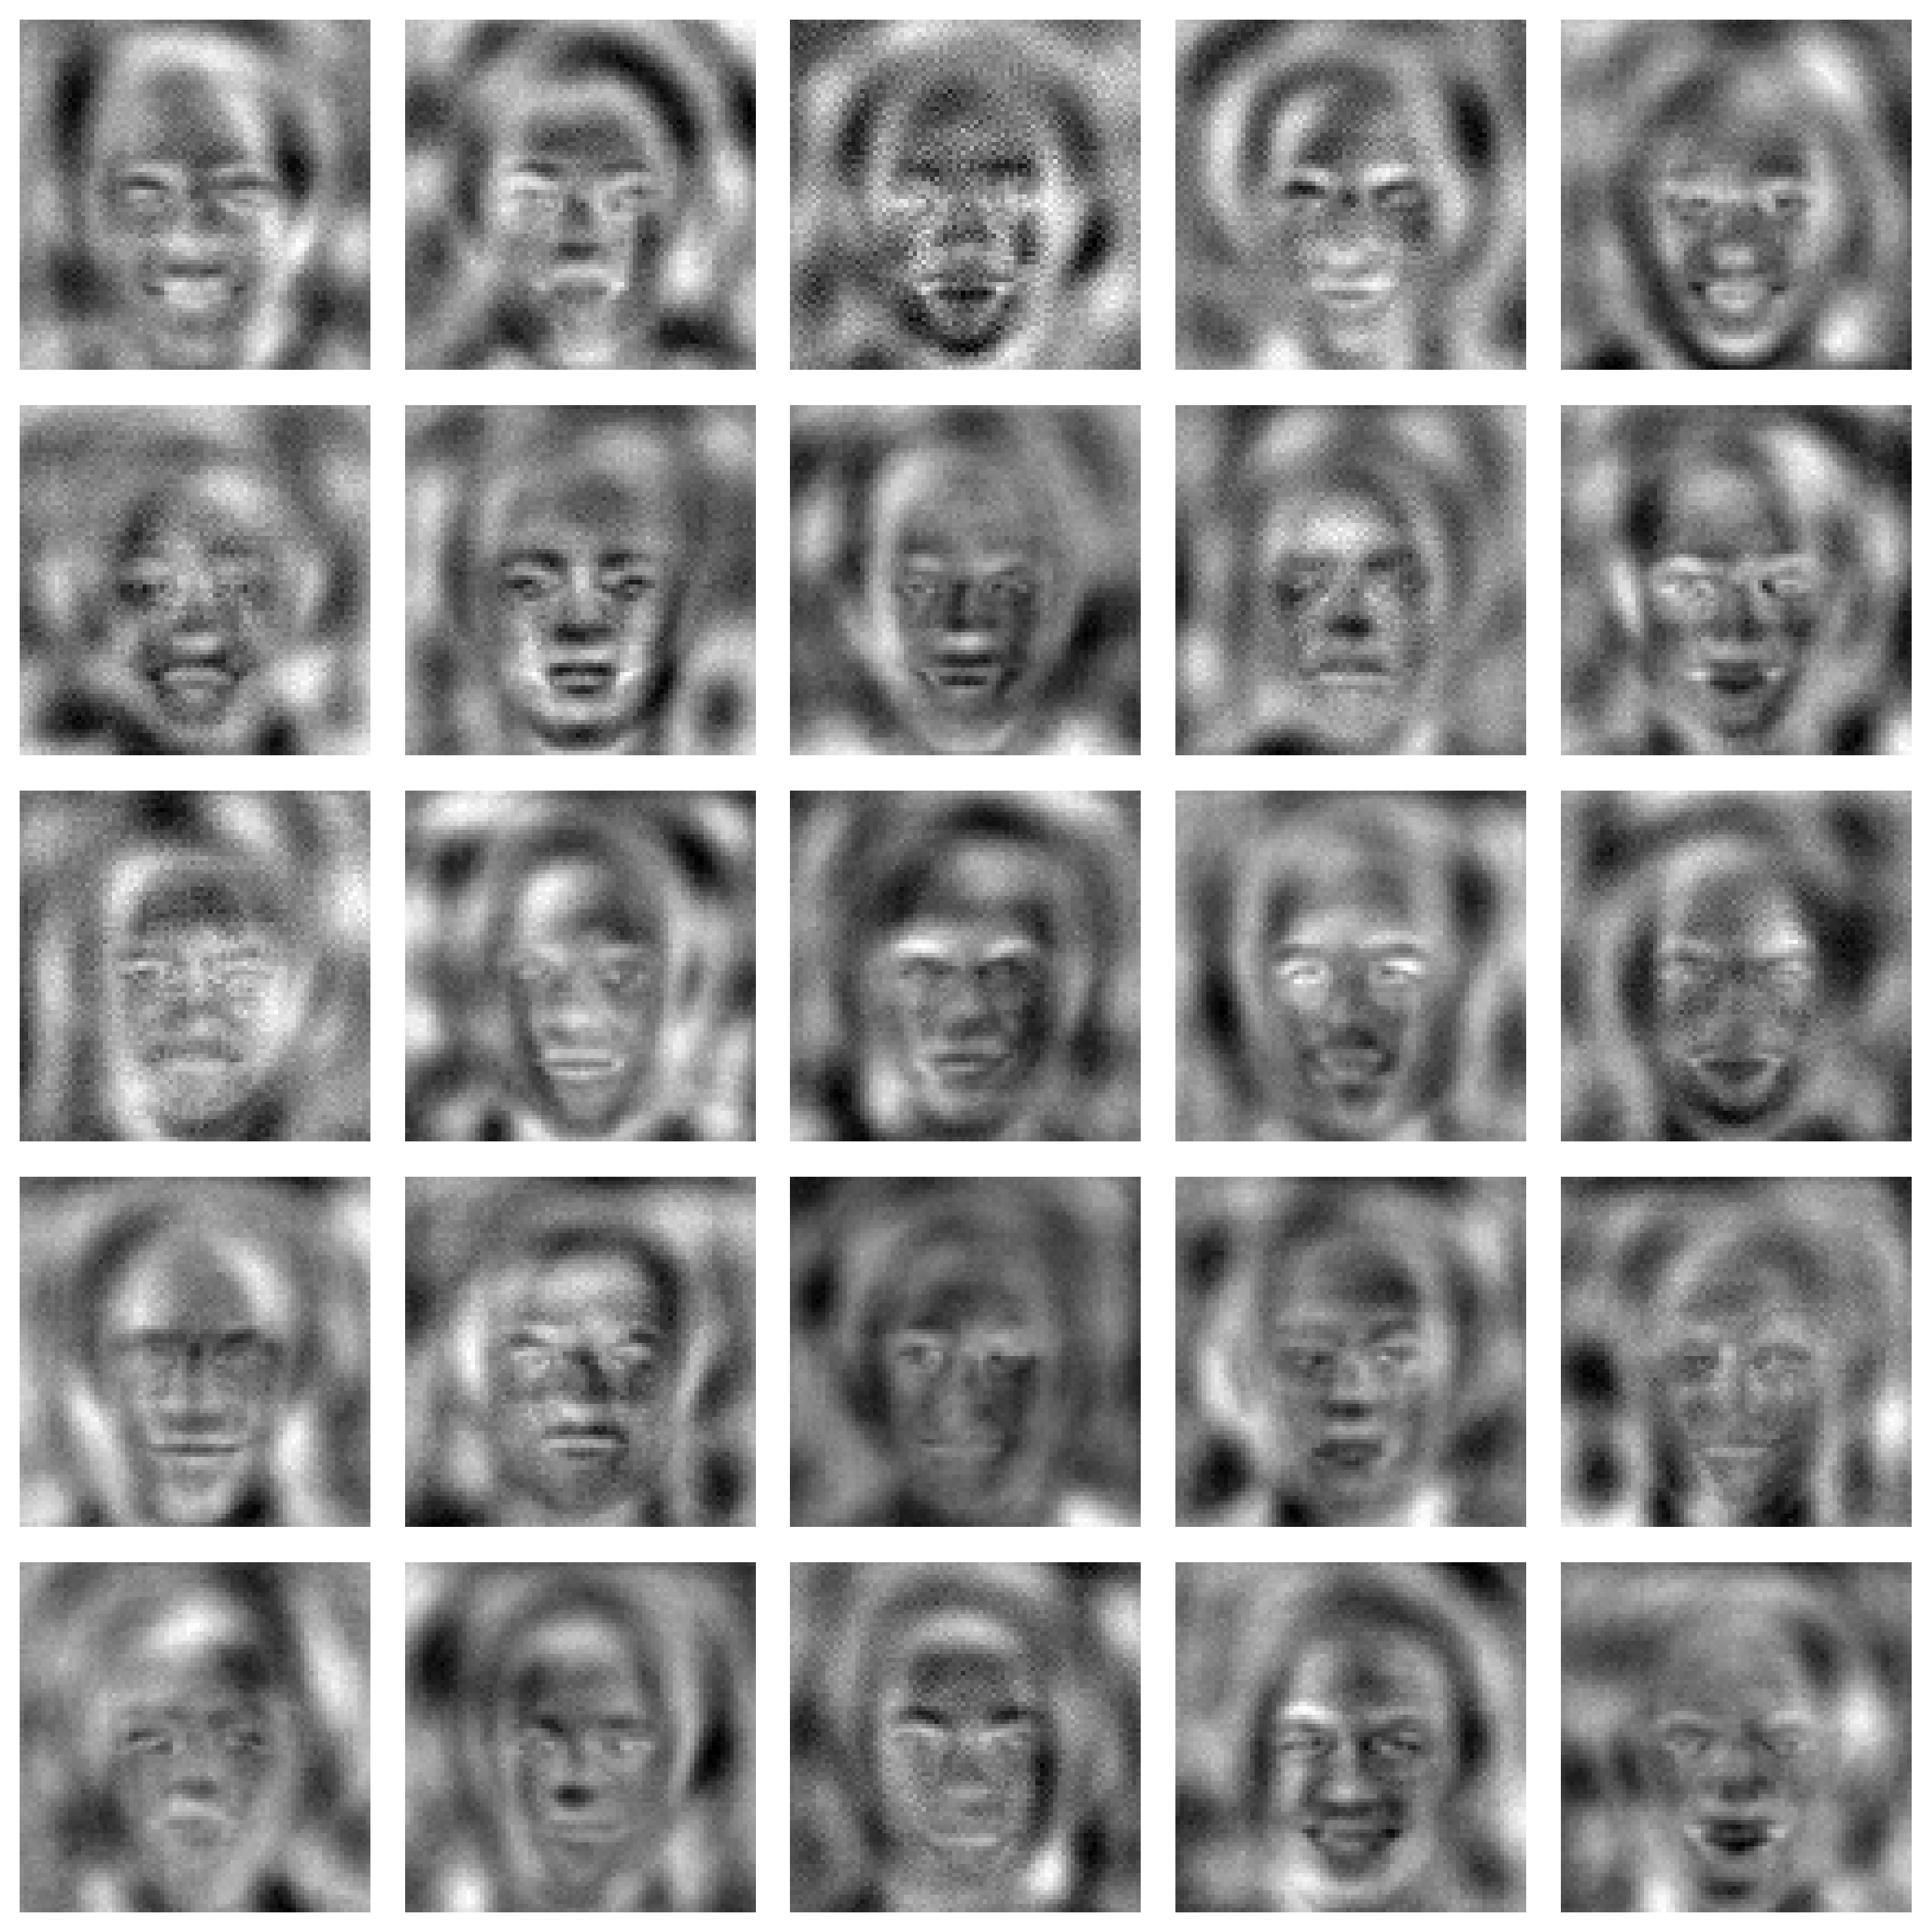

In [10]:
n_step = 2

n_row = 5
n_col = 5

fig, axs = plt.subplots(n_row, n_col, figsize=(n_col*2, n_row*2))
for idx in range(n_row * n_col):
    # normalization
    image = opt_image[idx * n_step]
    image = image - np.min(image)
    image = image / np.max(image)
    
    # show image
    axs.flat[idx].imshow(image, cmap='gray')
    axs.flat[idx].axis('off')
    
fig.tight_layout()

fig_name = 'celeba_olm'
fig.savefig('./%s.pdf' % fig_name, bbox_inches='tight')

Variance Drop-off

In [11]:
n_sample = 4096
pca_mtx = pca.components_[:n_sample, :]

base_path = './olm_result/CelebA/%d_MSE_celeba.npy'
file_path = base_path % n_sample

order = 5
with open(file_path, 'rb') as fl:
    for count in range(order):
        opt_mtx = np.load(fl)

# variance PC
pc_proj = pca_mtx @ image_vec.T
pc_var = np.var(pc_proj, axis=1)

# variance Opt Mtx
opt_proj = opt_mtx @ image_vec.T
opt_var = np.var(opt_proj, axis=1)
opt_sorted = np.sort(opt_var)[::-1]

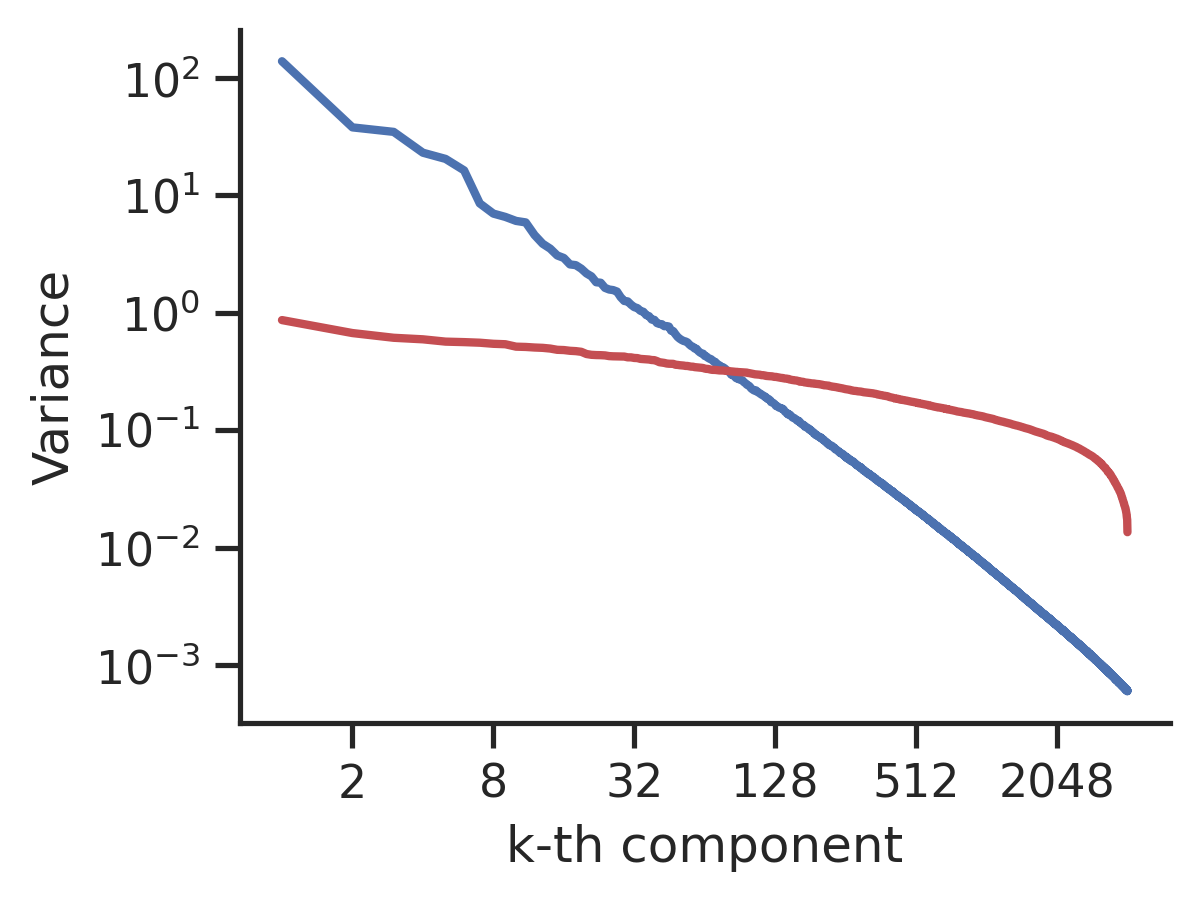

In [15]:
fig = plt.figure(figsize=(4, 3))

plt.plot(np.array(range(n_sample)) + 1, pc_var, linewidth=2)
plt.plot(np.array(range(n_sample)) + 1, opt_sorted, 'r', linewidth=2)

x_ticks = np.array([1, 3, 5, 7, 9, 11])
plt.xscale('log', base=2)
plt.xticks(2 ** x_ticks, 
           2 ** x_ticks)

plt.yscale('log')
plt.yticks(10.0 ** np.array([-3, -2, -1, 0, 1, 2]))
plt.minorticks_off()
plt.xlabel('k-th component')
plt.ylabel('Variance')

fig_name = 'celeba_var'
fig.savefig('./%s.pdf' % fig_name, bbox_inches='tight')

fig.show()

Linear Subspace

In [16]:
samples = [16, 32, 64, 
           128, 256, 512, 
           1024, 2048, 4096]

rand_mtx = np.random.normal(size=(n_pixel, n_pixel))
u, _, _ = np.linalg.svd(rand_mtx)

In [17]:
dist = [[], [], []]
pcs = pcs_celeba
split = split_celeba

for idx in range(len(samples)):
    n_sample = samples[idx]
    
    file_path = base_path % n_sample
    with open(file_path, 'rb') as fl:
        for count in range(order):
            opt_mtx = np.load(fl)
    
    # PC - PC
    fh = split[0][:n_sample, :]
    sh = split[1][:n_sample, :]
    angle = subspace_angles(fh.T, sh.T)
    dist[0].append(np.linalg.norm(angle))
    
    # PC - OPT
    pc = pcs[:n_sample, :]
    angle = subspace_angles(pc.T, opt_mtx.T)
    dist[1].append(np.linalg.norm(angle)) 
    
    # PC - RND
    rnd = u[:n_sample, :]
    angle = subspace_angles(pc.T, rnd.T)
    dist[2].append(np.linalg.norm(angle)) 

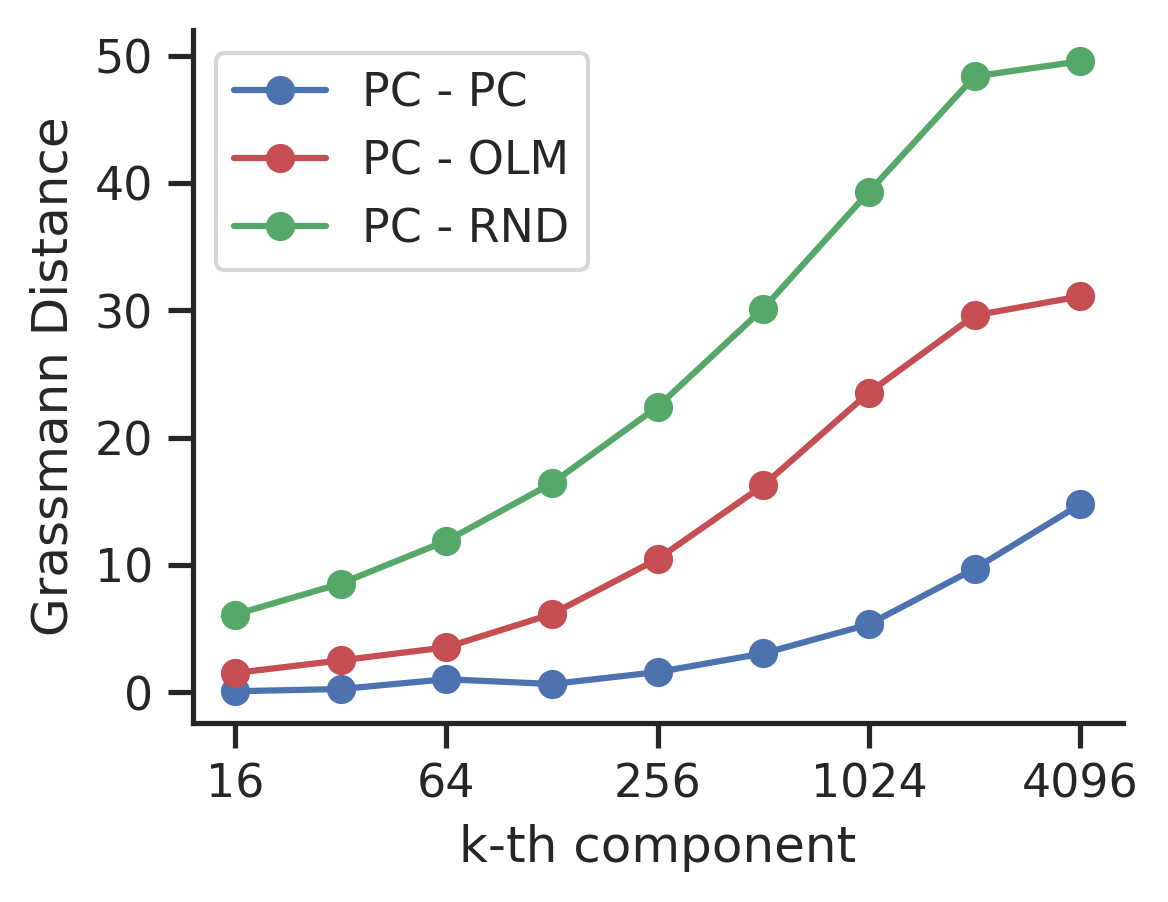

In [18]:
fig = plt.figure(figsize=(4, 3))

colors = ['b', 'r', 'g']
for idx in range(len(dist)):
    plt.plot(samples, dist[idx], '-o%s' % colors[idx])        

x_ticks = np.array([4, 6, 8, 10, 12])
plt.xscale('log', base=2)
plt.xticks(2 ** x_ticks, 
           2 ** x_ticks)

plt.legend(['PC - PC', 'PC - OLM', 'PC - RND'])

plt.xlabel('k-th component')
plt.ylabel('Grassmann Distance')

fig_name = 'celeba_dist'
fig.savefig('./%s.pdf' % fig_name, bbox_inches='tight')
    
plt.show()